In [ ]:
import torch
import gc

# Clear memory
gc.collect()
torch.cuda.empty_cache()

installing necessary libraries

In [ ]:
!pip install opencv-python

importing all the necessary libraries needed for the work

In [ ]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import cv2
import numpy as np
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from torch.utils.data import DataLoader
import torch
from torch.utils.data import Dataset

defining the functions needed for the pre-processing of the images

In [ ]:
def grayscale(image):
  return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [ ]:
#deskewing the image that we got

def getSkewAngle(cvImage) -> float:
  # Prep image, copy, convert to gray scale, blur, and threshold
  newImage = cvImage.copy()
  #gray = cv2.cvtColor(newImage, cv2.COLOR_BGR2GRAY)
  blur = cv2.GaussianBlur(newImage, (9, 9), 0)
  thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

  kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (30, 5))
  dilate = cv2.dilate(thresh, kernel, iterations=10)

  contours, hierarchy= cv2.findContours(dilate, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
  contours = sorted(contours, key = cv2.contourArea, reverse = True)
  for c in contours:
    rect = cv2.boundingRect(c)
    x,y,w,h = rect
    cv2.rectangle(newImage,(x,y),(x+w,y+h),(0,255,0),2)

  largestContour= contours[0]
  print(len(contours))
  minAreaRect = cv2.minAreaRect(largestContour)
  cv2.imwrite('mesia/boxes.jpg',newImage)

  angle = minAreaRect[-1]
  if angle < -45:
    angle = 90 + angle
  return -1.0 * angle

def rotateImage(cvImage, angle:float):
  newImage= cvImage.copy()
  (h, w) = newImage.shape[:2]
  center= (w // 2, h // 2)
  M = cv2.getRotationMatrix2D(center, angle, 1.0)
  newImage= cv2.warpAffine(newImage, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
  return newImage

def deskew(cvImage):
  angle = getSkewAngle(cvImage)
  return rotateImage(cvImage, -1.0 * angle)

testing the pre-processing on a simple example with only one simple img

In [ ]:
#img pre-processing
#transforming the image to arrays using cv2

img_path= '/media/test1.jpg'
image=cv2.imread(img_path)

img_gray=grayscale(image)
cv2.imwrite("/media/gray.jpg",img_gray)

thresh, image_bw= cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#thresh return the threshold value used

cv2.imwrite("/media/bw.jpg",image_bw)

#we need to convert the image to PIL format so we can give it to the model
final_img=Image.open("/media/bw.jpg")

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


adding more pre-processing to the img to improve the quality of the output by defining a new function: noise removal

In [ ]:
def noise_removal(image):

  #SHARPEN: This defines the edges so they don't bleed together
  kernel_sharpen = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
  image = cv2.filter2D(image, -1, kernel_sharpen)

  #a kernel is a small matrix that slides over your image to perform an operation
  kernel_closing = np.ones((3,1), np.uint8)

  #closing small holes
  image = cv2.morphologyEx(image, cv2.MORPH_CLOSE,kernel_closing)

  #blur with 3x3 area

  return (image)

applying the new function on the img

In [ ]:
no_noise= noise_removal(image_bw)
cv2.imwrite('/media/no_noise.jpg', no_noise)

True

In [ ]:
final_img=Image.open("/media/no_noise.jpg")

testing the same model on the new img saved after the noise removal

In [ ]:
#the ocr model

processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-handwritten')
model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-handwritten')
pixel_values = processor(images=final_img, return_tensors="pt").pixel_values

generated_ids = model.generate(pixel_values)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


NameError: name 'final_img' is not defined

priting the results and concluding that the result of OCR is getting better with the noise removal

In [ ]:
print(generated_text)

clean of Parliament's from Watch


time to fine-tune the model using a dataset consisting of photos of my own handwriting and labels containing the correct text

for this opeartion I'll be using GPU with CUDA

In [ ]:
!nvidia-smi

Wed Apr  8 15:53:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [ ]:
!pip install nvcc4jupyter
%load_ext nvcc4jupyter

Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmp7kq6gyc3".


importing the dataset by connecting the google drive in which i have uploaded the dataset folder

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Run this ONCE at the start of your notebook
import shutil
import os

print("Copying dataset to local runtime...")
shutil.copytree(
    "/content/drive/MyDrive/Annexes/dataset",  # your drive path
    "/content/dataset"                              # local path
)
print("Done!")

Copying dataset to local runtime...
Done!


uploading our model as per usual and getting started to train it using the new dataset

In [ ]:

model_id = "microsoft/trocr-base-handwritten"

processor = TrOCRProcessor.from_pretrained(model_id)
model = VisionEncoderDecoderModel.from_pretrained(model_id)

model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id           = processor.tokenizer.pad_token_id
model.config.vocab_size             = model.config.decoder.vocab_size

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (i

now, Loading the dataset in python

In [ ]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image, ImageFilter
import numpy as np
import cv2

MAX_LABEL_LENGTH = 256

class OCRDataset(Dataset):
    def __init__(self, root_dir, processor,
                 max_target_length=MAX_LABEL_LENGTH, train=True):
        self.root_dir = root_dir
        self.processor = processor
        self.max_target_length = max_target_length
        self.train = train

        # Lightweight augmentation only — no heavy transforms
        self.augment = transforms.Compose([
            transforms.RandomRotation(degrees=2),        # reduced from 3
            transforms.ColorJitter(brightness=0.2,       # reduced from 0.3
                                   contrast=0.2),
            # Removed RandomAffine — expensive + causes resampling
        ])

        # Load all labels once
        with open(f"{root_dir}/labels.txt", "r") as f:
            self.samples = [
                line.strip().split("|")
                for line in f if "|" in line
            ]

        # PRE-CACHE all images in memory at init time
        # This trades RAM for speed — done once not per epoch
        print("Caching images into memory...")
        self.cache = {}
        for img_name, _ in self.samples:
            img_path = f"{root_dir}/images/{img_name}"
            img = Image.open(img_path).convert("RGB")
            # Preprocess ONCE here (binarization is deterministic)
            self.cache[img_name] = self._preprocess(img)
        print(f"Cached {len(self.cache)} images")

    def _preprocess(self, image):
        """Deterministic preprocessing — run once at cache time"""
        img = np.array(image)
        img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        _, img_bw = cv2.threshold(
            img_gray, 0, 255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )
        img_bw = noise_removal(img_bw)
        return Image.fromarray(img_bw).convert("RGB")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_name, text = self.samples[idx]

        # Get from cache (already preprocessed)
        image = self.cache[img_name].copy()  # copy to avoid mutation

        # Apply augmentation AFTER loading from cache
        if self.train:
            image = self.augment(image)

        # Encode image
        pixel_values = self.processor(
            images=image,
            return_tensors="pt"
        ).pixel_values

        # Tokenize labels
        labels = self.processor.tokenizer(
            text,
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True,
            return_tensors="pt"
        ).input_ids

        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {
            "pixel_values": pixel_values.squeeze(0),
            "labels": labels.squeeze(0)
        }

In [ ]:
MAX_LABEL_LENGTH = 256

class OCRDataset(Dataset):
    def __init__(self, root_dir, processor, max_target_length=MAX_LABEL_LENGTH):
        self.root_dir          = root_dir
        self.processor         = processor
        self.max_target_length = max_target_length

        with open(f"{root_dir}/labels.txt", "r") as f:
            self.samples = [line.strip().split("|") for line in f if "|" in line]

    def preprocess(self, image):
        img       = np.array(image)
        img_gray  = grayscale(img)
        _, img_bw = cv2.threshold(img_gray, 0, 255,
                                   cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        no_noise  = noise_removal(img_bw)
        return Image.fromarray(no_noise).convert("RGB")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_name, text = self.samples[idx]

        image = Image.open(f"{self.root_dir}/images/{img_name}").convert("RGB")
        image = self.preprocess(image)

        # Encode image
        pixel_values = self.processor(images=image, return_tensors="pt").pixel_values

        # Tokenize labels with fixed max_length + replace pad with -100
        labels = self.processor.tokenizer(
            text,
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True,
            return_tensors="pt"
        ).input_ids

        # Replace padding token id with -100 so loss ignores it
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {
            "pixel_values": pixel_values.squeeze(0),
            "labels":       labels.squeeze(0)
        }

In [ ]:
dataset_path = "/content/dataset"
dataset = OCRDataset(root_dir=dataset_path, processor=processor)

Caching images into memory...
Cached 345 images


the training loop

In [ ]:
from transformers import get_scheduler

NUM_EPOCHS = 15

loader = DataLoader(dataset, batch_size=8, shuffle=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=100,
    num_training_steps=len(loader) * NUM_EPOCHS
)

model.train()

for epoch in range(NUM_EPOCHS):
    total_loss = 0.0

    for batch in loader:
        pixel_values = batch["pixel_values"].to(device)
        labels       = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss    = outputs.loss

        loss.backward()
        optimizer.step()
        scheduler.step()  # ← reduce lr gradually

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    print(f"Epoch {epoch + 1} | Avg Loss: {avg_loss:.4f}")

Epoch 1 | Avg Loss: 5.4262
Epoch 2 | Avg Loss: 0.9700
Epoch 3 | Avg Loss: 0.2897
Epoch 4 | Avg Loss: 0.1320
Epoch 5 | Avg Loss: 0.0907
Epoch 6 | Avg Loss: 0.2214
Epoch 7 | Avg Loss: 0.4525
Epoch 8 | Avg Loss: 0.0829
Epoch 9 | Avg Loss: 0.0530
Epoch 10 | Avg Loss: 0.0352
Epoch 11 | Avg Loss: 0.0669
Epoch 12 | Avg Loss: 0.0607
Epoch 13 | Avg Loss: 0.0199
Epoch 14 | Avg Loss: 0.0143
Epoch 15 | Avg Loss: 0.0110


evaluating the model

In [ ]:
def preprocess(image):
    img       = np.array(image)
    img_gray  = grayscale(img)
    _, img_bw = cv2.threshold(img_gray, 0, 255,
                               cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    no_noise  = noise_removal(img_bw)
    return Image.fromarray(no_noise).convert("RGB")

In [ ]:

# Load and preprocess the exact same way as training
image = Image.open("/media/test5.jpg").convert("RGB")
image = preprocess(image)

pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)

model.eval()
with torch.no_grad():
    generated_ids = model.generate(
        pixel_values,
        max_new_tokens=256  # tell it how long to generate
    )

predicted_text = processor.batch_decode(generated_ids, skip_special_tokens=True)
print("Predicted text:", predicted_text[0])

Predicted text: and the batch loop then proceed


**RQ: models gets the image instance from PIL (data type: PIL image), meanwhile the pre-processing is using CV2 (data type: np array)**

The desired pipeline: PIL → NumPy → OpenCV → NumPy → PIL

Saving the model on Google Collab

In [ ]:
import os

# Create a folder to save into
save_path = "/content/trocr-finetuned-15epochs"
os.makedirs(save_path, exist_ok=True)

# Save the model and processor
model.save_pretrained(save_path)
processor.save_pretrained(save_path)

print("Model saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully!


Saving the fine tuned model on Google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copytree(
    "/content/trocr-finetuned-15epochs",
    "/content/drive/MyDrive/trocr-finetuned-15epochs"
)

print("Saved to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to Google Drive!


Loading back the model from the drive to use it later on

In [ ]:
save_path = "/content/drive/MyDrive/trocr-finetuned"

processor = TrOCRProcessor.from_pretrained(save_path)
model = VisionEncoderDecoderModel.from_pretrained(save_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (i

Trying to identify the lines in the images to feed them then to the model

In [ ]:

# Load and preprocess the exact same way as training
image = Image.open("/media/part5.jpg").convert("RGB")
image = preprocess(image)

pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)

model.eval()
with torch.no_grad():
    generated_ids = model.generate(
        pixel_values,
        max_new_tokens=256
    )

predicted_text = processor.batch_decode(generated_ids, skip_special_tokens=True)
print("Predicted text:", predicted_text[0])

Predicted text: 


In [ ]:
image_np_original = cv2.imread("/media/test6.jpg")
gray      = cv2.cvtColor(image_np_original, cv2.COLOR_BGR2GRAY)
h, w      = gray.shape

_, thresh = cv2.threshold(gray, 0, 255,
                          cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

y = 0
i = 0
c= ''
k= h//12


while y + k <= h:
    strip   = thresh[y:y + k, :]
    roi_np  = image_np_original[y:y + k, :]

    preprocessed_pil_image = preprocess(roi_np)  # Assign to a new variable

    pixel_values = processor(images=preprocessed_pil_image, return_tensors="pt").pixel_values.to(device)
    model.eval()
    with torch.no_grad():
      generated_ids = model.generate(
      pixel_values,
      max_new_tokens=256
    )
    predicted_text = processor.batch_decode(generated_ids, skip_special_tokens=True)

    cv2.imwrite(f"/media/part{i}.jpg",roi_np)

    c += predicted_text[0]
    c += '\n'
    y += k
    i += 1

# Save leftover part at the bottom
if y < h:
    roi_leftover_np     = image_np_original[y:h, :]
    preprocessed_pil_image = preprocess(roi_leftover_np)  # Assign to a new variable

    pixel_values = processor(images=preprocessed_pil_image, return_tensors="pt").pixel_values.to(device)
    model.eval()
    with torch.no_grad():
      generated_ids = model.generate(
      pixel_values,
      max_new_tokens=256
    )
    predicted_text = processor.batch_decode(generated_ids, skip_special_tokens=True)

    c += predicted_text[0]

In [ ]:
print(c)

Taspernd: 1993 article
Tom OCRensure that uses Mess Learning
and a neural network and the chute called
is a Turing shot-Term Manual:
Pfeener:
Account Analysis: figures out where the
lines and words are composed
+) feature Extraction: breaks the image into
tiny math patterns vary from a
The network of output: mm
+) Exchange Model: Check: and to see the
wordenser in the
a number


In [ ]:
image = Image.open("/media/part3.jpg").convert("RGB")
image = preprocess(image)  # ← this was missing before
cv2.imwrite(f'/media/part_prepro.jpg', np.array(image))

True

trying to augment data

In [ ]:
from torchvision import transforms
from PIL import Image
import random

def augment_dataset(image_path, label, n=4):
    """Generate n augmented versions of each image"""
    img = Image.open(image_path).convert("RGB")
    augmented = []

    aug = transforms.Compose([
        transforms.RandomRotation(degrees=3),
        transforms.ColorJitter(
            brightness=0.3,
            contrast  =0.3
        ),
        transforms.RandomAffine(
            degrees   =0,
            translate =(0.02, 0.02),
            shear     =2
        ),
    ])

    for _ in range(n):
        augmented.append((aug(img), label))

    return augmented

# This turns 350 images into 1750

In [ ]:
augment_dataset("/media/test1.jpg", "this is a label")

[(<PIL.Image.Image image mode=RGB size=979x89>, 'this is a label'),
 (<PIL.Image.Image image mode=RGB size=979x89>, 'this is a label'),
 (<PIL.Image.Image image mode=RGB size=979x89>, 'this is a label'),
 (<PIL.Image.Image image mode=RGB size=979x89>, 'this is a label')]

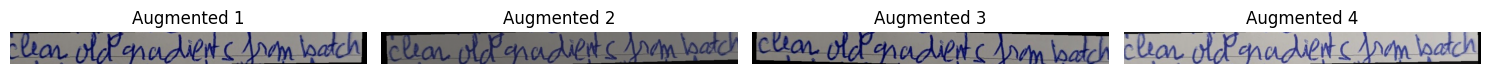

In [ ]:
import matplotlib.pyplot as plt

# 1. Run your function
image_path = "/media/test1.jpg"  # Replace with your actual path
results = augment_dataset(image_path, label="Example Class", n=4)

# 2. Setup the figure
fig, axes = plt.subplots(1, len(results), figsize=(15, 5))

# 3. Loop through and plot
for i, (aug_img, label) in enumerate(results):
    axes[i].imshow(aug_img)
    axes[i].set_title(f"Augmented {i+1}")
    axes[i].axis('off')  # Hide x/y numbers

plt.tight_layout()
plt.show()

In [ ]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import numpy as np
import cv2

MAX_LABEL_LENGTH = 256

class OCRDataset(Dataset):
    def __init__(self, root_dir, processor, max_target_length=MAX_LABEL_LENGTH, train=True):
        self.root_dir = root_dir
        self.processor = processor
        self.max_target_length = max_target_length
        self.train = train # Added to toggle augmentation

        # 1. PLACE AUGMENTATION LOGIC HERE
        self.augment = transforms.Compose([
            transforms.RandomRotation(degrees=3),
            transforms.ColorJitter(brightness=0.3, contrast=0.3),
            transforms.RandomAffine(degrees=0, translate=(0.02, 0.02), shear=2),
        ])

        with open(f"{root_dir}/labels.txt", "r") as f:
            self.samples = [line.strip().split("|") for line in f if "|" in line]

    def preprocess(self, image):
        # image here is already augmented (if training)
        img = np.array(image)
        img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) # Standardize grayscale
        _, img_bw = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        # Assuming your noise_removal function is defined elsewhere
        no_noise = noise_removal(img_bw)
        return Image.fromarray(no_noise).convert("RGB")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_name, text = self.samples[idx]
        image = Image.open(f"{self.root_dir}/images/{img_name}").convert("RGB")

        # 2. APPLY AUGMENTATION BEFORE PREPROCESSING
        if self.train:
            image = self.augment(image)

        # 3. RUN PREPROCESSING (Binarization/Noise Removal)
        image = self.preprocess(image)

        # Encode image
        pixel_values = self.processor(images=image, return_tensors="pt").pixel_values

        # Tokenize labels
        labels = self.processor.tokenizer(
            text,
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True,
            return_tensors="pt"
        ).input_ids

        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {
            "pixel_values": pixel_values.squeeze(0),
            "labels": labels.squeeze(0)
        }